# Quickstart

This quickstart builds a tiny system with a linear source feeding an integrator. You will connect the components, run a simulation, and plot the results.


## Import SysSimX

We use the `CoSimComponent`, `System`, and `Connection` classes, plus `matplotlib` for plotting.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from syssimx import CoSimComponent, Connection, System
from syssimx.core import PortSpec, PortType
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer


## Define the Components

We define a linear source `y = a * t + b` and a simple integrator that accumulates its input over time.


In [2]:
class LinearSource(CoSimComponent):
    """Linear source: y(t) = a * t + b."""

    def __init__(self, name: str, a: float = 1.0, b: float = 0.0):
        super().__init__(name, group="Source")
        self.a = a
        self.b = b
        self.output_specs.update({
            "y": PortSpec(name="y", type=PortType.REAL, direction="out")
        })

    def _initialize_component(self, t0: float) -> None:
        pass

    def _do_step_internal(self, t: float, dt: float) -> None:
        pass

    def _update_output_states(self, t: float | None = None, event_names=None):
        t_now = 0.0 if t is None else t
        self.outputs["y"].set(self.a * t_now + self.b, t)


class Integrator(CoSimComponent):
    """Integrator with explicit Euler stepping."""

    def __init__(self, name: str, x0: float = 0.0):
        super().__init__(name, group="Integrator")
        self.x0 = x0
        self.input_specs.update({
            "u": PortSpec(name="u", type=PortType.REAL, direction="in")
        })
        self.output_specs.update({
            "y": PortSpec(name="y", type=PortType.REAL, direction="out")
        })

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        u = self.inputs["u"].get()
        self.x += u * dt

    def _update_output_states(self, t: float | None = None, event_names=None):
        self.outputs["y"].set(self.x, t)


## Build the System

We connect the source output to the integrator input and initialize the system.


In [3]:
source = LinearSource(name="LinearSource", a=1.0, b=0.0)
integrator = Integrator(name="Integrator", x0=0.0)

system = System(name="QuickstartSystem")
system.add_component(source)
system.add_component(integrator)

system.add_connection(Connection(
    src_comp=source.name,
    src_port=source.output_specs["y"].name,
    dst_comp=integrator.name,
    dst_port=integrator.input_specs["u"].name,
))

system.initialize(t0=0.0)


## Visualize the System Graph

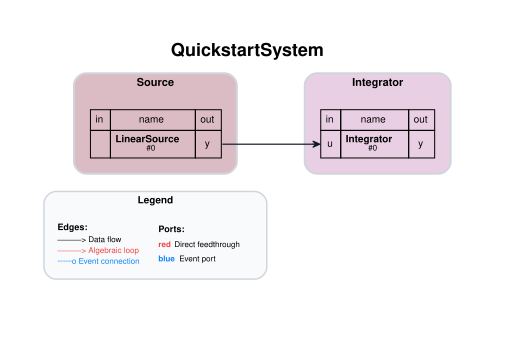

In [4]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()
visualizer.save("first_system_graph.svg")

## Run the Simulation

We simulate for 5 seconds with a fixed step size.


In [5]:
t0 = 0.0
tf = 5.0
dt = 0.1

system.run(t0=t0, tf=tf, dt=dt)


## Visualize Results

The integrator output is the integral of the linear source. For `a=1` and `b=0`, the expected shape is quadratic.


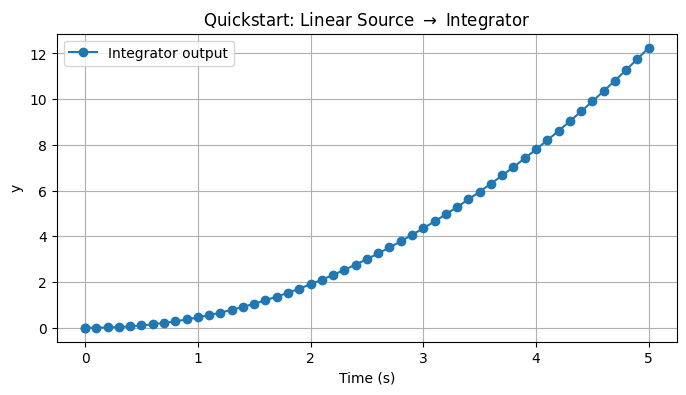

In [6]:
history = system.get_history()

t_vals, data = history["Integrator"]
y_vals = data["y"]

plt.figure(figsize=(8, 4))
plt.plot(t_vals, y_vals, label="Integrator output", marker="o")
plt.xlabel("Time (s)")
plt.ylabel("y")
plt.title("Quickstart: Linear Source $\\to$ Integrator")
plt.grid()
plt.legend()
plt.show()


## Next Steps

- See {doc}`/03_core_tutorials/01_beginners/02_first_system` for a slightly larger system with feedback.
- See {doc}`/03_core_tutorials/01_beginners/03_importing_fmus` for loading FMU components.